# Clash of Clans AI Base Designer
This notebook demonstrates the complete pipeline:
1. Load official Clash of Clans static data
2. Parse exported village JSON
3. Generate building summary
4. Load AI-generated layout
5. Render base
6. Export image



## 1. Import



In [10]:
from pathlib import Path
import json
import copy
import pandas as pd

from core.static_data_loader import StaticDataLoader
from core.export_parser import ExportParser
from core.building_summary import BuildingSummary
from core.render import BaseRenderer



## 2. Project Configuration



In [2]:
ROOT = Path.cwd()

DATA_DIR = ROOT / "data"
LAYOUT_DIR = ROOT / "doc" / "result"
OUTPUT_DIR = ROOT / "output"

OUTPUT_DIR.mkdir(exist_ok=True)

print(ROOT)



c:\xampp\htdocs\coc-base-designer


## 3. Load Static Data



In [3]:
loader = StaticDataLoader(
    DATA_DIR / "static_data.json"
)

print(f"Building Types : {loader.total_buildings()}")



Building Types : 76


## 4. Parse Official Export
Data eksport from clash of clans game official


In [4]:
with open(
    "data_export.json",
    "r",
    encoding="utf-8"
) as f:
    export_data = json.load(f)


print("Buildings :", len(export_data["buildings"]))



Buildings : 42


## 5. Generate Village Summary



In [17]:
summary = BuildingSummary(
    export_data,
    loader
)

village = summary.summarize()

print("Town Hall :", village["townhall_level"])
print("Buildings :", village["building_count"])
print("Walls     :", village["wall_count"])



Town Hall : 13
Buildings : 393
Walls     : 300


### 5.1 Building Summary



In [18]:
pd.DataFrame(village["buildings"])



,id,name,count,level,size,category,village
0,1000001,Town Hall,1,13,"[4, 4]",Town Hall,home
1,1000014,Clan Castle,1,9,"[3, 3]",Army,home
2,1000031,Eagle Artillery,1,4,"[4, 4]",Defense,home
3,1000067,Scattershot,2,2,"[3, 3]",Defense,home
4,1000027,Inferno Tower,3,6,"[2, 2]",Defense,home
5,1000021,X-Bow,4,5,"[3, 3]",Defense,home
6,1000012,Air Defense,4,9,"[3, 3]",Defense,home
7,1000028,Air Sweeper,2,7,"[2, 2]",Defense,home
8,1000009,Archer Tower,8,15,"[3, 3]",Defense,home
9,1000000,Army Camp,4,11,"[4, 4]",Army,home


### 5.1.1 Village to JSON for Genetic Algorithm
```
...
    {
      "id": 1000067,
      "name": "Scattershot",
      "count": 2,
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home"
    },
...
```
akan diubah mejadi
```
...
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home"
    },{
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home"
    },{
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home"
    },
...
```


In [19]:
def expand_buildings(village):

    expanded_buildings = []

    for building in village["buildings"]:

        count = building.get("count", 1)

        for instance in range(1, count + 1):

            new_building = copy.deepcopy(building)

            # Hapus count karena setiap object
            # sekarang mewakili satu bangunan
            new_building.pop("count", None)

            # Tambahkan instance
            new_building["instance"] = instance

            expanded_buildings.append(new_building)

    # Update jumlah building
    village["building_count"] = len(expanded_buildings)

    # Ganti data buildings
    village["buildings"] = expanded_buildings

    return village

In [20]:
village_expanded = expand_buildings(village)

print(village_expanded)

{'townhall_level': 13, 'building_count': 393, 'wall_count': 300, 'map_size': 44, 'buildings': [{'id': 1000001, 'name': 'Town Hall', 'level': 13, 'size': [4, 4], 'category': 'Town Hall', 'village': 'home', 'instance': 1}, {'id': 1000014, 'name': 'Clan Castle', 'level': 9, 'size': [3, 3], 'category': 'Army', 'village': 'home', 'instance': 1}, {'id': 1000031, 'name': 'Eagle Artillery', 'level': 4, 'size': [4, 4], 'category': 'Defense', 'village': 'home', 'instance': 1}, {'id': 1000067, 'name': 'Scattershot', 'level': 2, 'size': [3, 3], 'category': 'Defense', 'village': 'home', 'instance': 1}, {'id': 1000067, 'name': 'Scattershot', 'level': 2, 'size': [3, 3], 'category': 'Defense', 'village': 'home', 'instance': 2}, {'id': 1000027, 'name': 'Inferno Tower', 'level': 6, 'size': [2, 2], 'category': 'Defense', 'village': 'home', 'instance': 1}, {'id': 1000027, 'name': 'Inferno Tower', 'level': 6, 'size': [2, 2], 'category': 'Defense', 'village': 'home', 'instance': 2}, {'id': 1000027, 'name': 

### 5.2 Prompt for LLM

```
You are an expert Clash of Clans Home Village Base Designer.
Your task is to design a COMPLETE Clash of Clans Home Village layout.

Village Information

- Town Hall Level: 13
- Map Size: 44 x 44

Base Style: Farming Base
Primary Defensive Objective: Electro Dragon

Design Priorities (highest to lowest)
1. All placement rules MUST be satisfied.
2. No overlapping buildings.
3. Town Hall must be difficult to reach.
4. Clan Castle should cover the Town Hall.
5. Eagle Artillery should be protected.
6. Scattershots should be separated.
7. Inferno Towers should not be adjacent.
8. Heroes should help protect the Town Hall.
9. Storages should be used as defensive buffers.
10. Army buildings should be placed outside the core.
11. Collectors should be placed near the outer ring.
12. Builder Huts should occupy corners whenever possible.
13. Walls should create multiple compartments instead of one large compartment.
14. Symmetry is preferred but not required.

Before returning the JSON, internally verify all of the following:
✓ Every building count is correct.
✓ Every wall count is correct.
✓ No buildings overlap.
✓ Every building is inside the map.
✓ Town Hall exists exactly once.
✓ Clan Castle exists exactly once.
✓ Every building uses the correct level.
✓ Every building uses the correct _id.
✓ Every wall occupies exactly one tile.
If any rule is violated,
correct the layout before producing the final JSON.

Preferred Spacing Rules
• Eagle Artillery should not touch the Town Hall.
• Scattershots should be separated.
• Inferno Towers should protect different compartments.
• Air Defenses should cover different quadrants.
• X-Bows should cover the Town Hall.
• Bomb Towers should protect storages.
• Wizard Towers should cover resource storages.
• Mortars should not all be clustered together.
• Air Sweepers should point toward expected attack paths.

Forbidden Layouts
- Never place
- Town Hall beside Eagle.
- Scattershots beside each other.
- Infernos beside each other.
- All Air Defenses on one side.
- All Heroes together.
- Large empty areas.
- Disconnected walls.
- Single compartment bases.
- Buildings outside walls without reason.

Internally follow this order.
Step 1: Place Town Hall.
Step 2: Place Clan Castle.
Step 3: Place Eagle.
Step 4: Place Scattershots.
Step 5: Place Infernos.
Step 6: Place Air Defenses.
Step 7: Place X-Bows.
Step 8: Create wall compartments.
Step 9: Place remaining defenses.
Step 10: Place storages.
Step 11: Place collectors.
Step 12: Place army buildings.
Step 13: Place Builder Huts.

Only after all placements satisfy the constraints,
return the JSON.

Building List
	id	name	count	level	size	category	village
0	1000001	Town Hall	1	13	[4, 4]	Town Hall	home
1	1000014	Clan Castle	1	9	[3, 3]	Army	home
2	1000031	Eagle Artillery	1	4	[4, 4]	Defense	home
3	1000067	Scattershot	2	2	[3, 3]	Defense	home
4	1000027	Inferno Tower	3	6	[2, 2]	Defense	home
5	1000021	X-Bow	4	5	[3, 3]	Defense	home
6	1000012	Air Defense	4	9	[3, 3]	Defense	home
7	1000028	Air Sweeper	2	7	[2, 2]	Defense	home
8	1000009	Archer Tower	8	15	[3, 3]	Defense	home
9	1000000	Army Camp	4	11	[4, 4]	Army	home
10	1000006	Barracks	1	15	[3, 3]	Army	home
11	1000070	Blacksmith	1	6	[3, 3]	Army	home
12	1000032	Bomb Tower	2	6	[3, 3]	Defense	home
13	1000015	Builder's Hut	5	1	[2, 2]	Worker	home
14	1000008	Cannon	7	19	[3, 3]	Defense	home
15	1000026	Dark Barracks	1	10	[3, 3]	Army	home
16	1000023	Dark Elixir Drill	3	9	[3, 3]	Resource	home
17	1000024	Dark Elixir Storage	1	8	[3, 3]	Resource	home
18	1000029	Dark Spell Factory	1	6	[3, 3]	Army	home
19	1000002	Elixir Collector	7	15	[3, 3]	Resource	home
20	1000003	Elixir Storage	4	14	[3, 3]	Resource	home
21	1000004	Gold Mine	7	15	[3, 3]	Resource	home
22	1000005	Gold Storage	4	14	[3, 3]	Resource	home
23	1000093	Helper Hut	1	1	[3, 3]	Helper	home
24	1000071	Hero Hall	1	7	[4, 4]	Army	home
25	1000019	Hidden Tesla	5	9	[2, 2]	Defense	home
26	1000007	Laboratory	1	11	[3, 3]	Army	home
27	1000013	Mortar	4	12	[3, 3]	Defense	home
28	1000020	Spell Factory	1	7	[3, 3]	Army	home
29	1000010	Wall	300	14	[1, 1]	Wall	home
30	1000011	Wizard Tower	5	10	[3, 3]	Defense	home
31	1000059	Workshop	1	5	[4, 4]	Army	home

Output Format

Return ONLY valid JSON.

Do not use markdown.
Do not explain anything.
Do not write comments.

The JSON schema MUST be:

{
    "townhall_level": 13,
    "buildings": [
        {
            "_id" = "1000001"
            "level": 13,
            "row": 20,
            "col": 20
        }
    ],
    "walls": [
        {
            "row": 18,
            "col": 19
        }
    ]
}


```

## 6. Load AI Layout



### 6.1 Load from file

In [ ]:
with open(
    LAYOUT_DIR / "2" / "deepseek_deeplearng.json",
    encoding="utf-8"
) as f:

    layout = json.load(f)

print(
    f"Buildings : {len(layout['buildings'])}"
)

print(
    f"Walls : {len(layout['walls'])}"
)



Buildings : 93
Walls : 355


## 7. Render



Layout:
{'_id': '1000001', 'level': 13, 'row': 20, 'col': 20}

Building:
{'_id': 1000001, 'name': 'Town Hall', 'info': "\\nThis is the heart of your Village! Upgrade your Town Hall to unlock new Defenses, Buildings, Traps, and much more.\\n\\nDestroying an opponent's Town Hall earns you one star in battle. Protect your Town Hall from attacks by placing it in the middle of your Village and surrounding it with Walls, Traps and Defenses.", 'TID': {'name': 'TID_BUILDING_TOWN_HALL', 'info': 'TID_TOWN_HALL_INFO'}, 'type': 'Town Hall', 'upgrade_resource': 'Gold', 'village': 'home', 'width': 4, 'superchargeable': False, 'levels': [{'level': 1, 'build_cost': 0, 'build_time': 0, 'required_townhall': 0, 'hitpoints': 400, 'dps': 0, 'unlocks': [{'name': 'Army Camp', '_id': 1000000, 'quantity': 1}, {'name': 'Elixir Storage', '_id': 1000003, 'quantity': 1}, {'name': 'Gold Storage', '_id': 1000005, 'quantity': 1}, {'name': 'Elixir Collector', '_id': 1000002, 'quantity': 1}, {'name': 'Gold Mine', '_id'

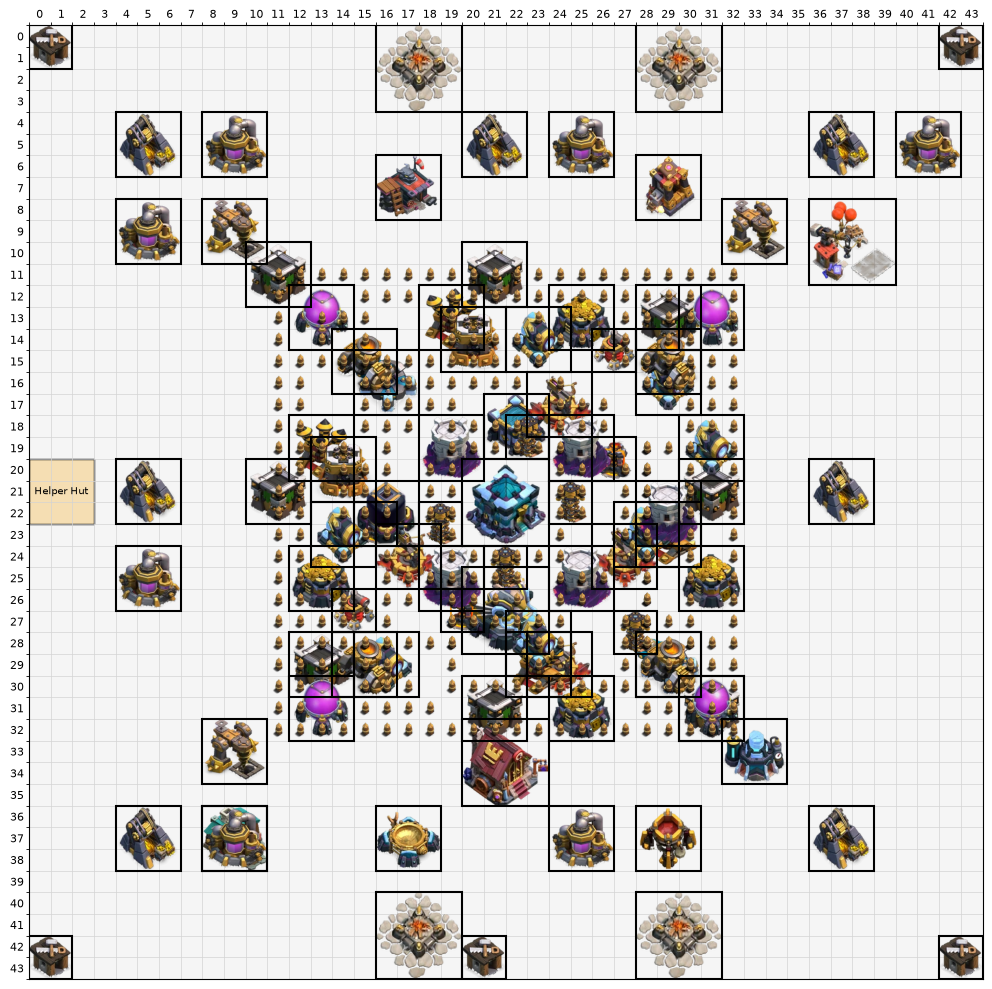

In [12]:
renderer = BaseRenderer(loader)

fig, ax = renderer.render(layout)



## 8. Save



In [13]:
renderer.save(
    fig,
    OUTPUT_DIR / "output.png"
)

print("Done.")


Saved : c:\xampp\htdocs\coc-base-designer\output\output.png
Done.
